# PyG HeteroData export

`to_pyg` exports an AnnNet graph to PyTorch Geometric
`HeteroData` for graph neural network workflows.


In [1]:
import annnet as an

an.info()


Version,v0.2.0
License,BSD-3-Clause
Authors,"Youssef Zerta ✉, Daniele Bottazzi ✉, Denes Turei ✉"
Repository,https://github.com/saezlab/annnet
Documentation,https://saezlab.github.io/annnet/reference/
Default graph backend,networkx
Default plot backend,graphviz
Graph backends,✓networkx✓igraph✗graph-tool✓pyg
Plot backends,✓graphviz✗pydot✓matplotlib
Tabular data backends,✓polars✓pandas✓pyarrow
I/O modules,✓annnet✓json/ndjson✓dataframes✓csv✓excel✓graphml/gexf✓sif✓cx2✓parquet✓zarr✗sbml✓scverse✓omnipath


## Build a heterogeneous graph


In [2]:
G = an.AnnNet(directed=True)
G.add_vertices('p1', kind='protein', activity=1.2, abundance=4.0)
G.add_vertices('p2', kind='protein', activity=-0.4, abundance=2.5)
G.add_vertices('g1', kind='gene', expression=8.0, length=1200.0)
G.add_vertices('drug_a', kind='drug', dosage=10.0, approved=1.0)

G.add_edges('p1', 'g1', edge_id='regulates', weight=0.8)
G.add_edges('p2', 'g1', edge_id='represses', weight=-0.6)
G.add_edges('drug_a', 'p1', edge_id='targets', weight=0.5)
G.add_edges('drug_a', 'p2', edge_id='off_target', weight=0.25)
G.slices.add('train')
G.slices.add_edges('train', ['regulates', 'represses'])

G.views.vertices()


vertex_id,kind,activity,abundance,expression,length,dosage,approved
str,str,f64,f64,f64,f64,f64,f64
"""p1""","""protein""",1.2,4.0,null,null,null,null
"""p2""","""protein""",-0.4,2.5,null,null,null,null
"""g1""","""gene""",null,null,8.0,1200.0,null,null
"""drug_a""","""drug""",null,null,null,null,10.0,1.0


## Draw the source graph


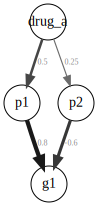

In [3]:
from annnet.utils import plotting

plotting.plot(G, backend='graphviz', show_edge_labels=True)


## Export to PyG and run a tensor operation


In [4]:
import torch

data = an.to_pyg(
    G,
    node_features={
        'protein': ['activity', 'abundance'],
        'gene': ['expression', 'length'],
        'drug': ['dosage', 'approved'],
    },
    slice_id='train',
    hyperedge_mode='skip',
)
data.validate(raise_on_error=True)

protein_activity = data['protein'].x[:, 0]
activity_probability = torch.sigmoid(protein_activity)
homogeneous = data.to_homogeneous()

print(data)
print('protein activity:', protein_activity.tolist())
print('sigmoid(activity):', activity_probability.tolist())
print('homogeneous edge_index shape:', tuple(homogeneous.edge_index.shape))


HeteroData(
  manifest={
    node_index={
      protein={
        p1=0,
        p2=1,
      },
      gene={ g1=0 },
      drug={ drug_a=0 },
    },
    edge_index={},
  },
  protein={
    x=[2, 2],
    train_mask=[2],
  },
  gene={
    x=[1, 2],
    train_mask=[1],
  },
  drug={
    x=[1, 2],
    train_mask=[1],
  },
  (protein, edge, gene)={
    edge_index=[2, 2],
    edge_weight=[2],
  },
  (drug, edge, protein)={
    edge_index=[2, 2],
    edge_weight=[2],
  }
)
protein activity: [1.2000000476837158, -0.4000000059604645]
sigmoid(activity): [0.7685248255729675, 0.40131235122680664]
homogeneous edge_index shape: (2, 4)


AnnNet remains useful before tensorization: it stores names,
metadata, slices, and graph semantics. `to_pyg` is the boundary
where selected numeric attributes become tensors.
